Question 4.1

In [27]:
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = [X+Y for X,Y in zip(x,y)] 
print("z=", z)


z= [11, 22, 33, 50]


In [26]:
def addd(x,y):
    return x+y

x = [1,2,3,10]
y = [10, 20, 30, 40]
z = map(addd, x,y)
print("z=", list(z))

z= [11, 22, 33, 50]


Question 4.3

In [46]:
import numpy as np
RPS1 = input("Input rock, paper or scissors by inputting R, P or S: ") #The user can input R, P or S

RPS = np.array(['R', 'P', 'S'])
indx = np.random.randint(0, len(RPS), 1) # The computer draws R, P or S randomly
print("The computers choise is", RPS[indx]) # The computer runs shows what he drew

if RPS1 == 'R' and RPS[indx] ==  'S' : # For each combination the programm shows 'who' wins.
    print("You win")
if RPS1 == 'R' and RPS[indx] ==  'P' :
    print("You lose")
if RPS1 == 'R'and RPS[indx] == 'R' :
    print("DRAW")
if RPS1 == 'S' and RPS[indx] == 'S' :
    print("DRAW")
if RPS1 == 'S' and RPS[indx] ==  'P' :
    print("You win")
if RPS1 == 'S' and RPS[indx] ==  'R' :
    print("You lose")
if RPS1 == 'P'and RPS[indx] ==  'S' :
    print("You lose")
if RPS1 == 'P' and RPS[indx] ==  'P' :
    print("DRAW")
if RPS1 == 'P' and RPS[indx] ==  'R' :
    print("You win")
    

Input rock, paper or scissors by inputting R, P or S:  P


The computers choise is ['P']
DRAW


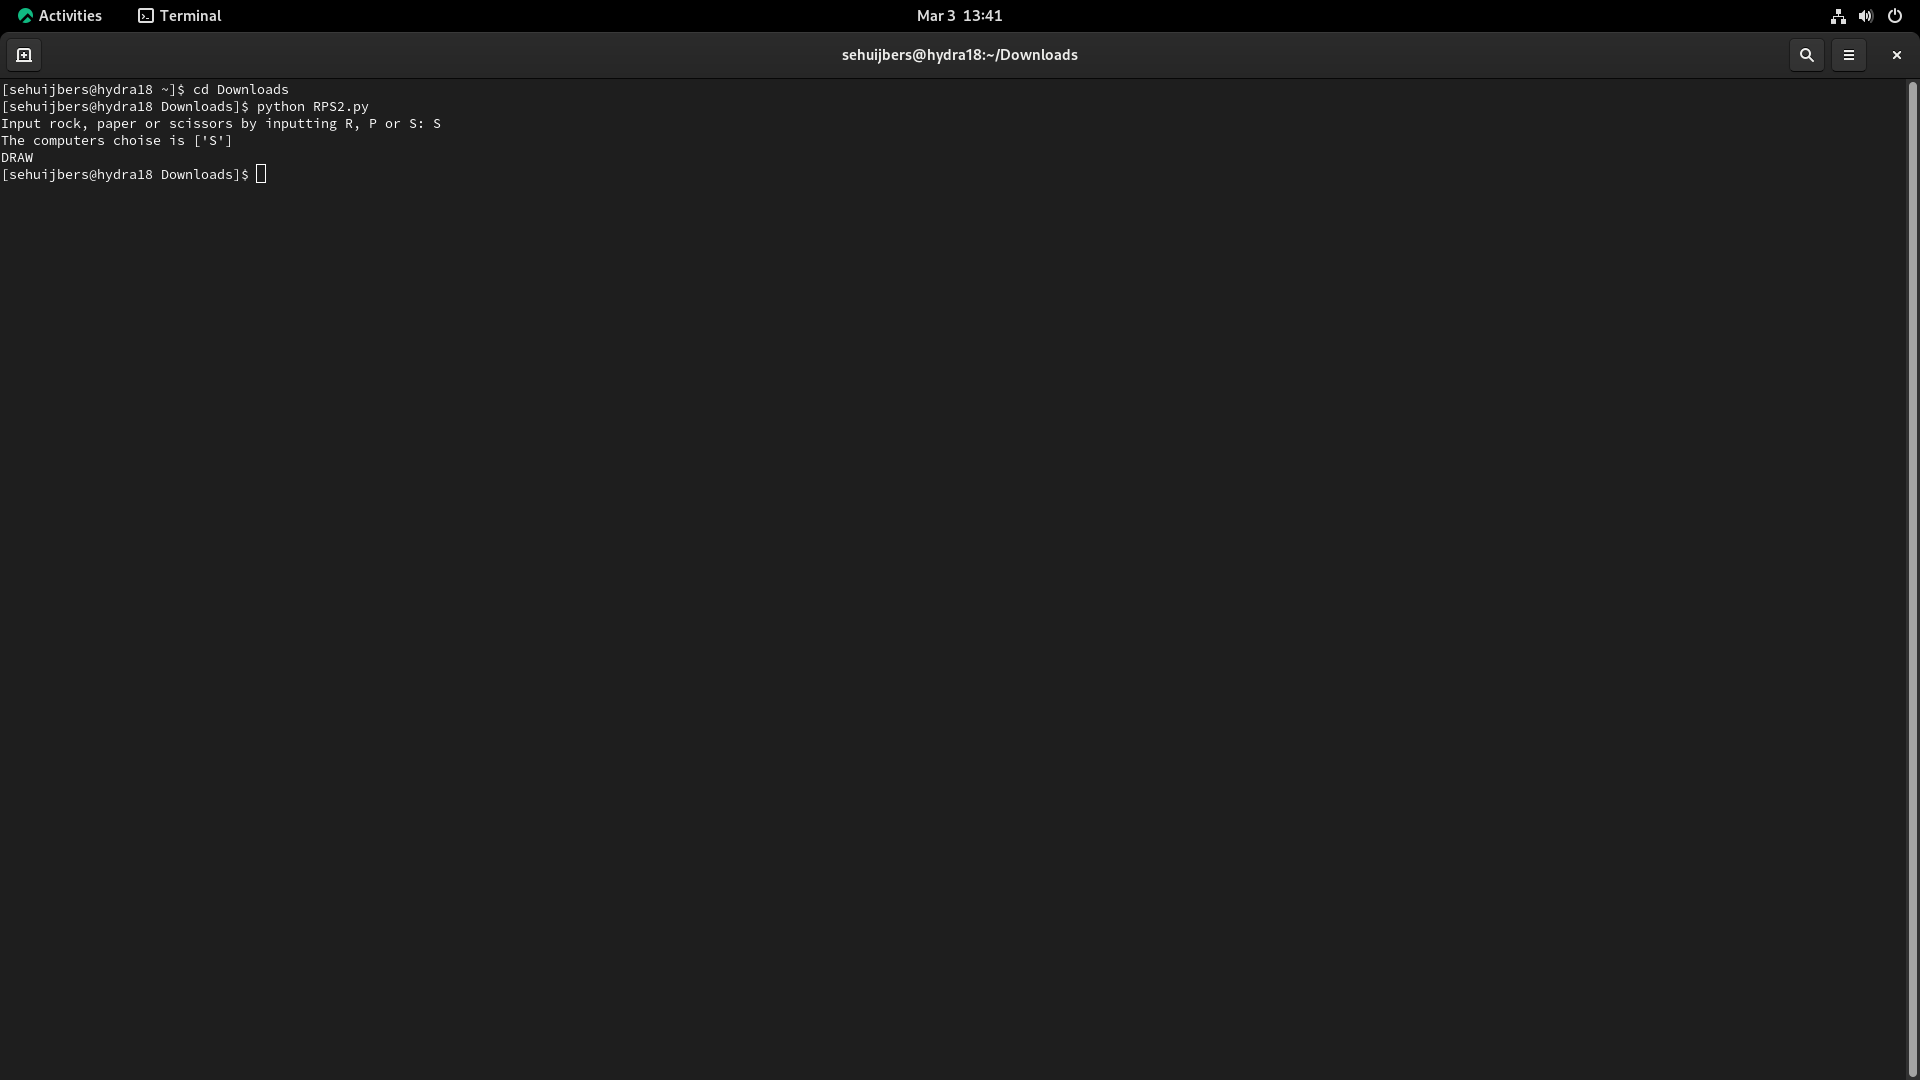

Question 4.3

Subset of random lengths: [186.12415652 184.51862559 170.23951628 182.13812936 176.66841409
 186.73261141 184.52689183 173.65000547 190.31692398 184.22309191]
The standard diviation of this histogram is: 8.036532345383126
The mean of this histogram is 185.0071719833339


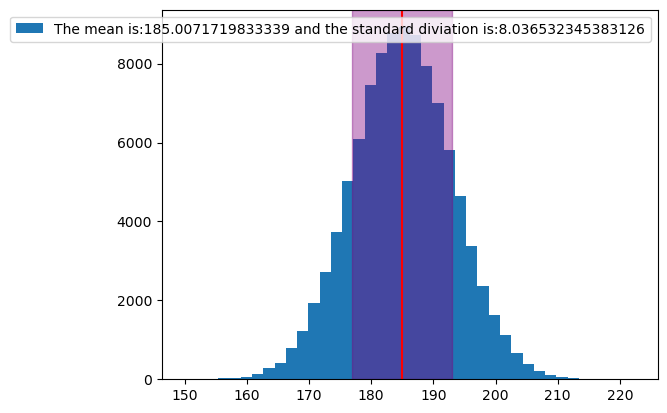

Input length  200


Probability to find a length of 200 cm or smaller in our sample is: 96.96 %
Probability to find a height located within 1 standard deviation range 68.49 %


In [4]:
import numpy as np
from scipy.stats import norm
lengths = np.random.normal(185, 8, 100000) # Input points for the Gaussian distribution
print("Subset of random lengths:", lengths[:10]) # To print a subset of the random lengths

import numpy as np
numpylist = np.array(lengths) # Convert to list to be able to use np.std and np.mean
numpystd = np.std(numpylist)
numpymean = np.mean(numpylist)

print(f"The standard diviation of this histogram is: {numpystd}")
print(f"The mean of this histogram is {numpymean}")

from matplotlib import pyplot as plt # Import to be able to make a plot
plt.hist(lengths, bins=40,label=f"The mean is:{numpymean} and the standard diviation is:{numpystd}" ) #bin=40 for 40 stripes in the histogra,
plt.legend() # To be able to make a legend


plt.axvline(numpymean, color='red') # To make a line at the mean
plt.axvspan(numpymean-numpystd,numpymean+numpystd, alpha = 0.4, color = "purple") #To color the field around the mean

plt.show()


h = input("Input length ") # With this you can calculate the chance to find a person smaller than the input height
cdf = norm.cdf(int(h), scale=8, loc=185)
P = 1 - cdf
P *= 100 # to percentage
Q = 100 - P
print(f"Probability to find a length of {h} cm or smaller in our sample is: {Q:.2f} %") 

less = norm.cdf(numpymean-numpystd, scale=8, loc=185) # With this you can calculate the chance to find a person smaller than the input height
more = norm.cdf(numpymean+numpystd, scale=8, loc=185)
percentage = (more-less)*100
print(f"Probability to find a height located within 1 standard deviation range {percentage:.2f} %")


Question 4.6 

In [37]:
import numpy as np
from math import *
# To make the user input a function a lower boundary and a upperboundary
func = input("Input a function in terms of x")
lowb = float(input("Input the lower boundary"))
uppb =float(input("Input the upper boundary"))

x = np.random.uniform(lowb,uppb,1000) # To make little steps between the upper and lower boundary
def mc(func,lowb, uppb):
    ans = (uppb-lowb)/len(x)*np.sum(eval(func)) # eval evaluates the function for every x, than it gets summed.
    return ans

print(mc(func,lowb,uppb))

Input a function in terms of x x
Input the lower boundary 0
Input the upper boundary 1


0.5078480172361991


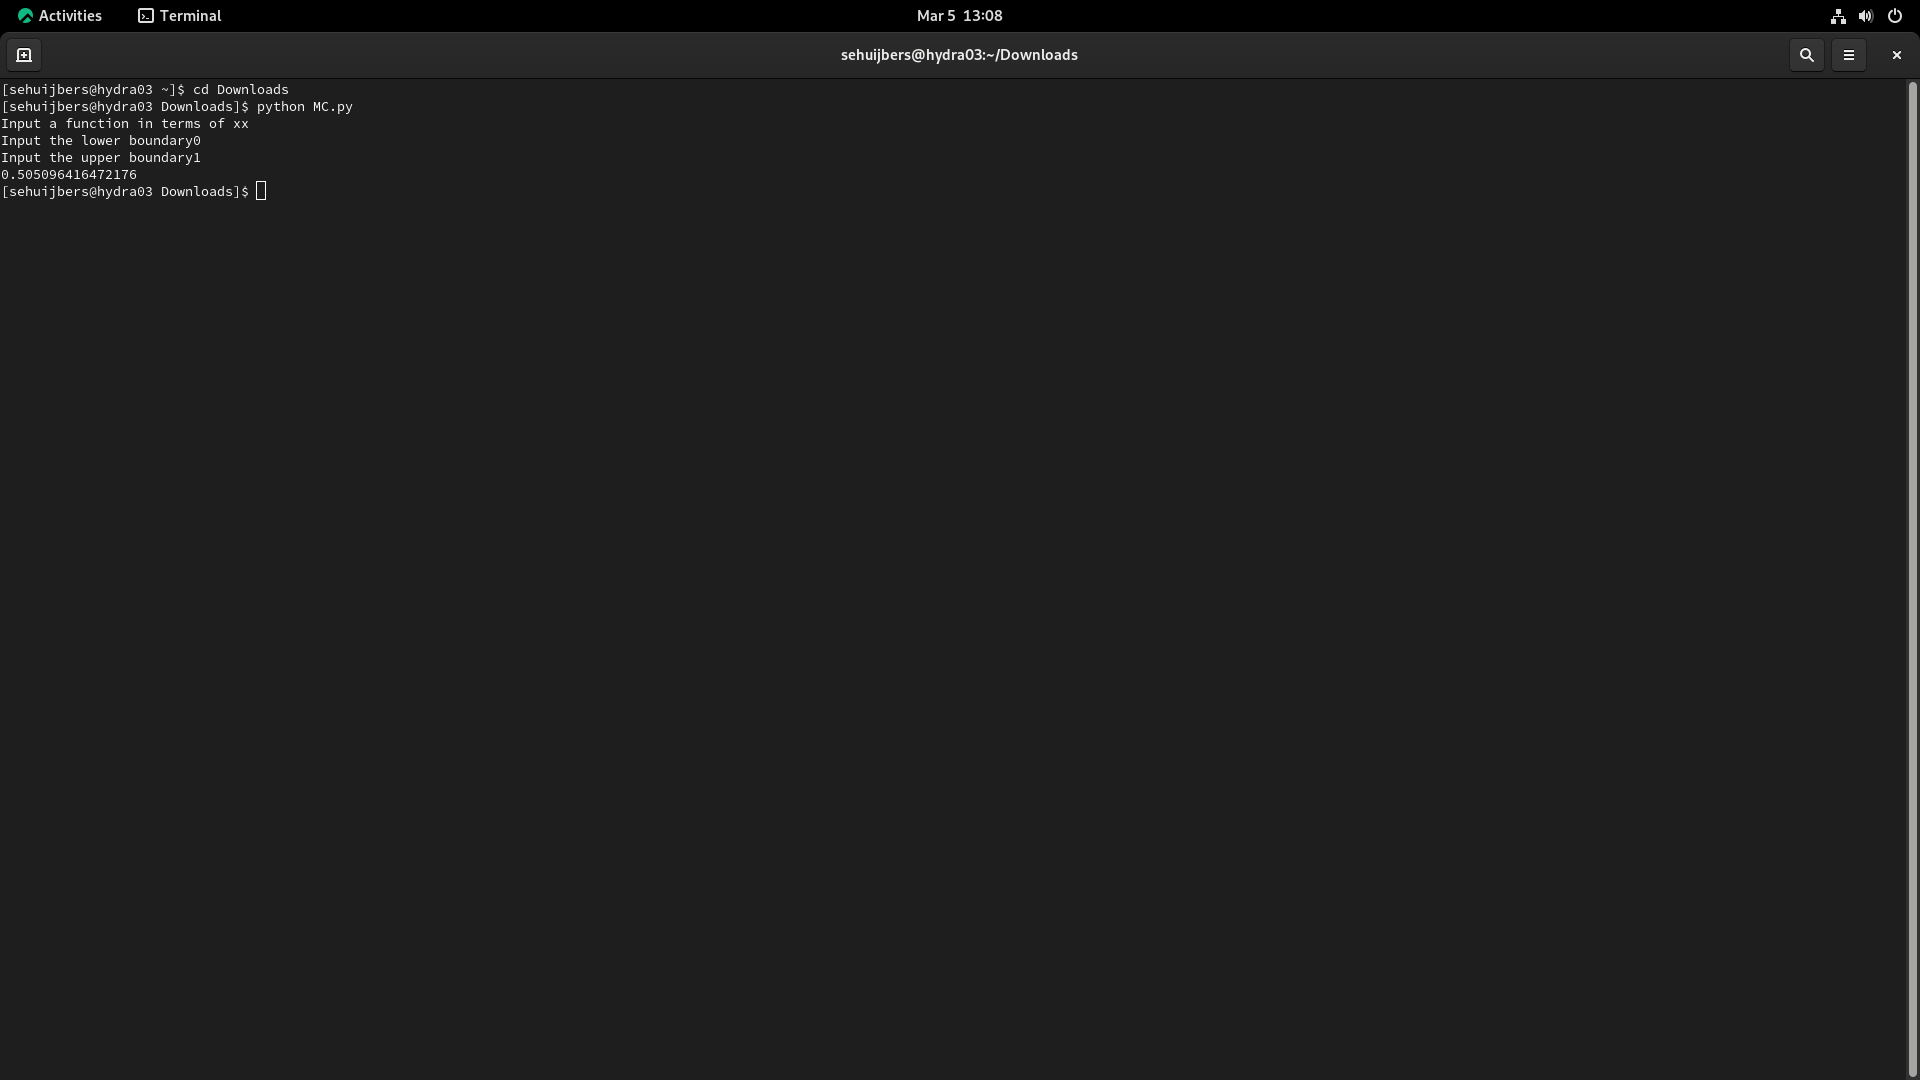

Question 4.7 : Error propagation with Monte Carlo



$$ \Delta g = \sqrt{(\frac{4\pi^2 \Delta L}{T^2})^2 +(\frac{-8\pi^2 L \Delta T}{T^3})^2} $$

In [60]:
from math import *
import numpy as np
L = 1.00
errL = 0.01
T = 2.01
errT = 0.02  # Given values

g = (4*pi**2*L)/(T)**2 # Calcutlate using formula
print(f"calculated with the derrived g, g is: {g}")

errg = sqrt(((4*(pi**2)*errL)/(T**2))**2 +((-8*(pi**2)*L*errT)/(T**3))**2) # Calcutlate error using  derrived formula
print(f"calculated with the derrived g, the error of g is: {errg}")

mcL = np.random.normal(1.00, 0.01, 1000) # Make a Gausssian distribution with the value and error
mcT = np.random.normal(2.01, 0.02, 1000)

arrmcL = np.array(mcL) # Make a array of the Gausssian distribution 
arrmcT = np.array(mcT)

gs = [] # Create a new list
for r in range(0,500,1):
    ranL = np.random.randint(0, len(arrmcL), 1)  # Draw a random point in the Gaussian distribution
    ranT = np.random.randint(0, len(arrmcT), 1)
    rang = (4*(pi**2)*arrmcL[ranL])/(arrmcT[ranT]**2)
    gs.append(rang) # Add the random points in the list

meang = np.mean(gs) # Use numpy to calculate the mean and the standard diviation
stdg = np.std(gs)

print(f"calculated with the Monte Carlo Error Propagation , g is: {meang}")
print(f"calculated with the Monte Carlo Error Propagation, the error of g is: {stdg}")

calculated with the derrived g, g is: 9.77164367326488
calculated with the derrived g, the error of g is: 0.21763137533582413
calculated with the Monte Carlo Error Propagation , g is: 9.757989541661477
calculated with the Monte Carlo Error Propagation, the error of g is: 0.2148534851671651


Question 4.11 : Complex roots of a quadratic equation

In [67]:
from math import *
import cmath # Import cmath to be able to also calculate for complex values 
a = input("value for a")
b = input("value for b")
c = input("value for c")

a = float(a)
b = float(b)
c = float(c)

D = b**2 - 4*a*c

if D > 0:
    x1 = (-b + sqrt(D))/(2*a)
    x2 = (-b -sqrt(D))/(2*a)
    b = f"the answers are  (-{b} + sqrt({D}))/(2*{a}) = {x1} and (-{b} - sqrt({D}))/(2*{a}) = {x2}"
    print(b)
    f1 = a*x1**2+b*x1+c
    f2 = a*x2**2+b*x2+c
    print(f"and the answer is true. since if we fill in {x1} we get {f1} and {x2} we get {f2}")

elif D==0:
    x = (-b + sqrt(D))/(2*a)
    b = f"the answer is (-{b} + sqrt({D}))/(2*{a}) = {x1}"
    print(b)
    f = a*x**2+b*x+c
    print(f"and the answer is true. since if we fill in {x} we get {f}")

else: # when D<0 the answer is complex a c-math has to be used
    x1 = (-b + cmath.sqrt(D))/(2*a)
    x2 = (-b - cmath.sqrt(D))/(2*a)
    print(f"The complex answers are (-{b} + sqrt({D}))/(2*{a}) = {x1} and (-{b} - sqrt({D}))/(2*{a}) = {x2}")
    f1 = a*x1**2+b*x1+c
    f2 = a*x2**2+b*x2+c
    print(f"and the answer is true. since if we fill in {x1} we get {f1} and {x2} we get {f2}")

value for a 1
value for b 2
value for c 5


The complex answers are (-2.0 + sqrt(-16.0))/(2*1.0) = (-1+2j) and (-2.0 - sqrt(-16.0))/(2*1.0) = (-1-2j)
and the answer is true. since if we fill in (-1+2j) we get 0j and (-1-2j) we get 0j


Question 4.12 : Rotate a square

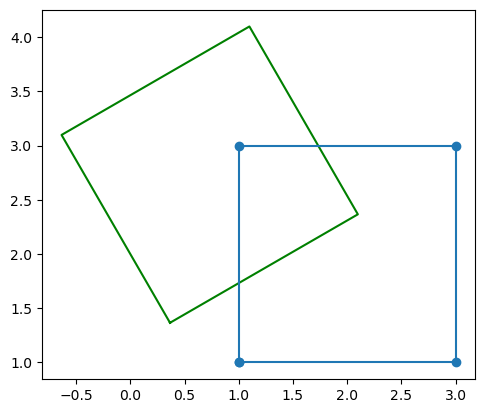

In [78]:
from matplotlib import pyplot as plt
from math import radians, cos, sin
from cmath import exp as cexp
import numpy as np


x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

theta = radians(30)
rotor = cos(theta) + sin(theta)*1j
XY = rotor * (x+y*1j)
plt.gca().set_aspect(1)
plt.plot(XY.real, XY.imag, color = 'green')
plt.plot(x,y)

plt.scatter(x,y)
plt.show()



In [79]:
def scaling(value, bscale=1, bzero=0):
    """ Scale a value with bscale and add offset bzero"""
    result1 = bscale*value + bzero
    result2 = bscale * value
    return result1, result2

val = 3
r1, r2 = scaling(val, 2, 0.01)
print(r1, r2)

6.01 6


Question 4.14 : Passing functions as arguments

In [99]:
import numpy as np
def funcfilter(func, seq) :
    l = np.asarray(seq)
    pl = [] # Make a  list for all the value greater than 0
    if np.ndim(l) == 0:   # When the dimension is 0 (a scalar) the scalar will convert to a list
        l = np.array([l])
    for p in l:
        if p > 0: # When p is bigger than zero it adds to the list
            pl.append(p)
    arrpl = np.array(pl)
    fpl = func(arrpl) # Applies the function
    return fpl

# Test 1   
f = funcfilter(np.log10, np.array([-100, -10, 0, 10, 100]))
print("Result log10, test 1:", f)

# Test 2
f = funcfilter(np.log10,100)
print("Result log10, test 2:", f)

Result log10, test 1: [1. 2.]
Result log10, test 2: [2.]


Question 4.16 : Calculating integration using quad()


In [9]:
from astropy.cosmology import Planck18 # Import constants

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

from scipy import integrate
from math import *

def H(z):
    y = H0*sqrt(Om0*(1+z)**3+Ode0) # Make a function to calculate Hz
    return y

def integral(z): # Make a function to put into the integral
    return 1/((1+z)*H(z))

a = 0
z = 2 # Take 2 as a test


t, err = integrate.quad( integral, a, z) # Integrate!!!!
t2 = t *3.0856e19 # Convert to seconds
t3 = t2/(60*60*24*365.25*1000000000) # Convert to Gyr
print("the lookback time in origanal units:", t) 
print("he lookback time in seconds", t2)
print("The lookback time in Gyr", t3)

the lookback time in origanal units: 0.010765276277273951
he lookback time in seconds 3.3217336481156506e+17
The lookback time in Gyr 10.525938753630347


Question 4.17 : Area under a Gaussian

the area between x=0 and x=2.5 is 1.9769788548675902


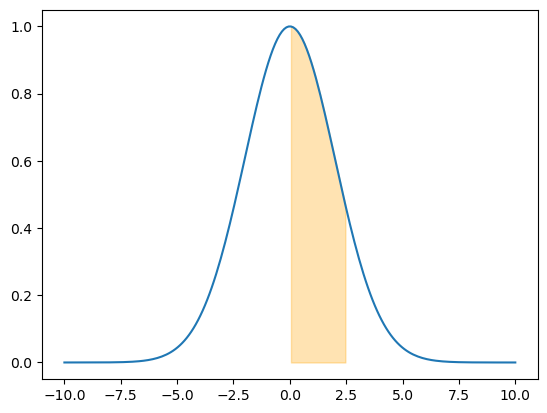

the area between x=-infinity and x=infinity is 5.013256549262001
the area calculated with the Area formula between x=-infinity and x=infinity is 5.013256549262001
5.0132565492620005


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import integrate

def gauss(x, A, x0, sig, z0): #The formula for Gaussian distribution
   return A*np.exp(-(x-x0)**2/(2*sig**2))+z0

A = 1.0 # All the given constants
x0 = 0.0
sig = 2.0
z0 = 0.0
x = np.linspace(-10, 10, 200) #To generate 200 samples on the gaussian distriution
plt.plot(x, gauss(x, A, x0, sig, z0)) #To plot the samples

a=0 #Bounderies for the first integration
b=2.5

t, err = integrate.quad( gauss, a, b, args=(A, x0, sig, z0)) #The first integration using quad
print(f"the area between x=0 and x=2.5 is {t}")

x_fill = x[(x >= a) & (x <= b)] #The bounderies for where to fill
y_fill = gauss(x_fill, A, x0, sigma, z0)
plt.fill_between(x_fill, y_fill, color='orange', alpha=0.3,)

plt.show()

c=-np.inf  #Bounderies for the seconde integration
d=np.inf

t2, err2 = integrate.quad( gauss, c, d, args=(A, x0, sig, z0)) #The second integration using the first formula
print(f"the area between x=-infinity and x=infinity is {t2}")

def Area(x, A, x0, sig, z0): #The Area formula
   return A*np.exp(-(x-x0)**2/(2*sig**2))
t3, err3 = integrate.quad( Area, c, d, args=(A, x0, sig, z0)) #The second integration using the Area formula
print(f"the area calculated with the Area formula between x=-infinity and x=infinity is {t2}")

t4 = A*sig*sqrt(2*pi) #The second integration using this "simple" formula
print(f" The area under the Gaussian distribution with the simple formula is {t4}")


Question 4.21 : Histograms

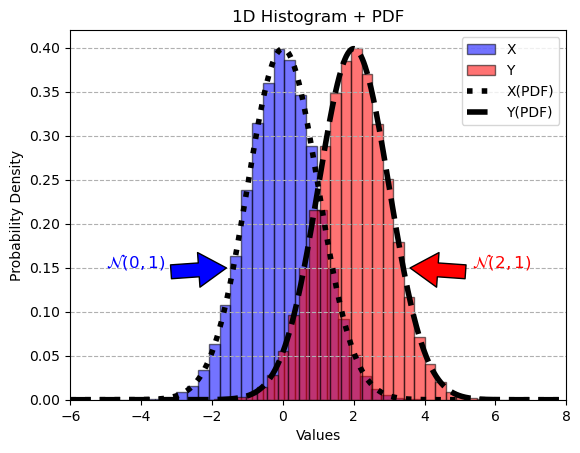

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# number of samples
num_points = 100000

# generate Gaussian datasets
data_A = np.random.normal(loc=0, scale=1, size=num_points)
data_B = np.random.normal(loc=2, scale=1, size=num_points)

# create the figure
plt.figure()

# histograms
plt.hist(data_A, bins=30, density=True, alpha=0.55,
         color='blue', edgecolor='black', label='X')

plt.hist(data_B, bins=30, density=True, alpha=0.55,
         color='red', edgecolor='black', label='Y')

# range for smooth PDF curves
z_values = np.linspace(-6, 8, 1000)

# theoretical PDFs
pdf_A = norm.pdf(z_values, 0, 1)
pdf_B = norm.pdf(z_values, 2, 1)

# plot PDFs
plt.plot(z_values, pdf_A, 'k:', linewidth=4, label='X(PDF)')
plt.plot(z_values, pdf_B, 'k--', linewidth=4, label='Y(PDF)')

# plot formatting
plt.title("1D Histogram + PDF")
plt.xlabel("Values")
plt.ylabel("Probability Density")

plt.xlim(-6, 8)
plt.ylim(0, 0.42)

plt.grid(axis='y', linestyle='--')
plt.legend()

# annotations with arrows
plt.annotate(r'$\mathcal{N}(0,1)$',
             xy=(-1.5, 0.15),
             xytext=(-5, 0.15),
             arrowprops=dict(facecolor='blue', shrink=0.05,
                             width=10, headwidth=25, headlength=20),
             color='blue',
             fontsize=12)

plt.annotate(r'$\mathcal{N}(2,1)$',
             xy=(3.5, 0.15),
             xytext=(7, 0.15),
             arrowprops=dict(facecolor='red', shrink=0.05,
                             width=10, headwidth=25, headlength=20),
             color='red',
             fontsize=12,
             ha='right')

plt.show()

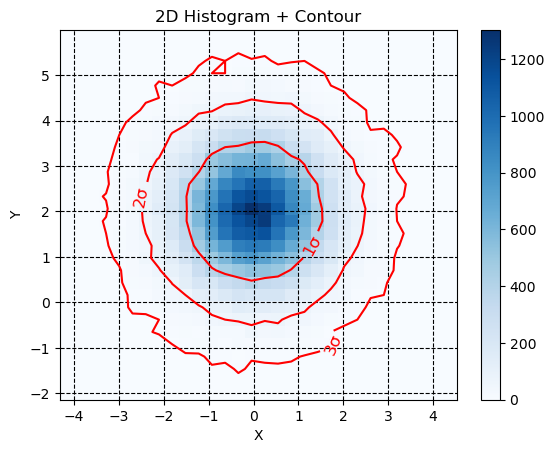

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# number of random samples
sample_size = 100000

# generate Gaussian data
data_x = np.random.normal(loc=0, scale=1, size=sample_size)
data_y = np.random.normal(loc=2, scale=1, size=sample_size)

# 2D histogram
hist_values, x_bins, y_bins, img = plt.hist2d(data_x, data_y, bins=30, cmap='Blues')

# add color bar to show density scale
plt.colorbar()

# flatten histogram and sort counts (largest first)
sorted_counts = np.sort(hist_values.flatten())[::-1]

# cumulative sum to determine probability regions
cumulative = np.cumsum(sorted_counts)

# compute contour levels for 1σ, 2σ, 3σ
sigma_levels = [
    sorted_counts[np.argwhere(cumulative <= fraction * sample_size)[-1][0]]
    for fraction in [0.68, 0.95, 0.997]
]

# compute bin centers for contour plotting
x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2

# draw contour lines
contours = plt.contour(
    x_centers,
    y_centers,
    hist_values.T,
    levels=sigma_levels[::-1],
    colors='red'
)

# label contour levels
plt.clabel(
    contours,
    inline=True,
    fmt={sigma_levels[0]:'1σ', sigma_levels[1]:'2σ', sigma_levels[2]:'3σ'},
    fontsize=12
)

# plot formatting
plt.title("2D Histogram + Contour")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(color='black', linestyle='--')

plt.show()